# TP MongoDB — Transformez vos documents !

Dans le TP précédent, vous avez découvert comment construire un pipeline d’agrégation pour filtrer, regrouper, calculer et trier des données.
Mais l’Aggregation Framework ne sert pas uniquement à faire des calculs !
Il permet également de transformer la structure des documents au fur et à mesure de leur passage dans le pipeline.

Imaginez que votre application stocke un document contenant de nombreux champs, mais que vous souhaitiez retourner uniquement :
* le nom d’une entreprise et ses bureaux ;
* ajouter un nouveau champ calculé ;
* supprimer certaines informations inutiles ;
* transformer la structure d’un tableau ou d’un document imbriqué.

Faut-il modifier les documents stockés dans la collection ?

Non ! L’Aggregation Framework permet de transformer les documents uniquement dans le résultat du pipeline, sans modifier les données originales.

:::{important} Objectifs techniques

Dans ce TP, vous allez apprendre à :

* transformer la structure d’un document dans un pipeline ;
* sélectionner les champs à retourner avec $project ;
* ajouter ou modifier des champs avec $set ;
* supprimer des champs avec $unset ;
* créer de nouveaux champs à partir de valeurs existantes ;
* manipuler des tableaux et des documents imbriqués ;
* combiner plusieurs stages pour obtenir la structure de document souhaitée.

::: 

Le principe à retenir, les documents stockés dans MongoDB restent inchangés :

```
Documents de la collection
          │
          ▼
      $project
          │
          ▼
        $set
          │
          ▼
       $unset
          │
          ▼
 Document transformé
```

Les stages du pipeline permettent donc non seulement d’analyser les données, mais également de leur donner la forme dont nous avons besoin.

À vous maintenant de transformer vos documents !

## Pré-requis

Depuis la racine du dépôt, placez-vous dans `docker`. Démarrez le service et vérifiez son état :

:::bash
cd docker
docker compose up -d mongosingle
docker compose ps mongosingle
:::

Chargez les documents des collections companies et trips nécessaire à ce TP. 

:::bash
docker compose run --rm loaddatatripsintomongosingle
docker compose run --rm loaddatacompaniesintomongosingle
:::

Vérifiez le résultat des commandes :

:::bash
2026-09-25T07:42:58.915+0000	dropping: training.trips
2026-09-25T07:42:59.266+0000	10000 document(s) imported successfully. 0 document(s) failed to import.

2026-09-25T07:42:59.723+0000	dropping: training.companies
2026-09-25T07:43:00.886+0000	9500 document(s) imported successfully. 0 document(s) failed to import.
:::

Pour ce TP, les commandes seront à executer dans votre client NoSQLBooster.

## Introduction

Nous utiliserons pour ce TP la collection companies dont voici un exemple de structure :

## Comment transformer un document ?

`$project`, `$set` et `$unset` sont des étapes du pipeline d’agrégation qui permettent de transformer la structure des documents.

Commençons par $project, cette stage permet de définir les champs que l’on souhaite conserver, exclure ou calculer dans les documents transmis à l’étape suivante du pipeline.

On peut le rapprocher de la projection utilisée en second argument de find().

Par exemple :

```
db.companies.find(
    { },
    { name: 1, offices: 1 }
)
```
Dans un pipeline d’agrégation, l’équivalent peut s’écrire :

```
db.companies.aggregate(
[
    {
        $project: {
            name: 1,
            offices: 1
        }
    }
])
```

L’exemple ci-dessus limite donc la projection aux champs name et offices. Le champ _id est toutefois conservé par défaut. Pour le masquer, il faut explicitement préciser :

{
    $project: {
        _id: 0,
        name: 1,
        offices: 1
    }
}

Limiter les champs transmis aux étapes suivantes peut également permettre de réduire la quantité de données manipulée dans le pipeline.

```
db.companies.aggregate([
{ $limit: 10 },
{ $project : { _id : 1, name: 1, offices: 1 }},
])
```

Uniquement les clés valuées à 1 seront retournées par ```$project```.

On peut aussi ajouter de nouveaux champs :

```
db.companies.aggregate([
{ $limit: 10 },
{ $project : { _id : 1, name: 1, offices: 1, newfield: 'c est trop fort'}}
])
```

:::{warning} Attention
Les stages lié à la projection `$project`,`$set`, `$unset` ne modifient jamais les documents stockés dans la collection. Ils transforment uniquement la représentation des documents qui circulent dans le pipeline d’agrégation.
 :::

On peut réorganiser les documents sous la forme que l'on souhaite.
Dans cet exemple, on crée un sous document deadpool qui regroupe tous les attributs préfixés par deadpool :
* deadpooled_year
* deadpooled_month
* deadpooled_day.

```
db.companies.aggregate([
{ $limit: 3 },
{ $project : { _id : 1, deadpooled: { deadpooled_year: "$deadpooled_year",deadpooled_month: "$deadpooled_month", deadpooled_day: "$deadpooled_day", deadpooled_url: "$deadpooled_url"} ,offices: 1 }},
])
```

D’autres stages, comme `$set` et `$unset`, viennent compléter `$project` :
* `$set` : ajoute de nouveaux champs ou modifie la valeur de champs existants, tout en conservant les autres champs du document.
https://www.mongodb.com/docs/manual/reference/operator/aggregation/set/
* `$unset` : à l’inverse, supprime un ou plusieurs champs du document.
https://www.mongodb.com/docs/manual/reference/operator/aggregation/unset/

:::{warning} Attention
$set dans l'aggrégation framework est un stage et ne correspond pas à l'opérateur utiliser pour mettre à jour des documents.
:::

Il est parfois possible d’obtenir un résultat similaire à `$project` en combinant `$set` et `$unset`. Cependant, lorsque l’objectif est de ne conserver qu’un nombre limité de champs, `$project` est généralement plus simple et plus lisible : avec `$unset`, il faudrait explicitement supprimer tous les champs dont on ne souhaite pas conserver la valeur.


```
db.companies.aggregate([
  { $limit: 3 },
  {
    $set: {
      deadpooled: {
        year: "$deadpooled_year",
        month: "$deadpooled_month",
        day: "$deadpooled_day",
        url: "$deadpooled_url"
      }
    }
  },
  {
    $unset: [
      "deadpooled_year",
      "deadpooled_month",
      "deadpooled_day",
      "deadpooled_url"
    ]
  }
])
```

En résumé, `$project` façonne le document retourné, `$set` ajoute ou modifie des champs et `$unset` en supprime.

:::{warning} Attention
La projection sur une clé de type tableau implique que la nouvelle clé de projection sera elle même un tableau.
Un exemple sera sûrement plus parlant ;-).
:::

L'exemple ci-dessous regroupe l'ensemble des noms de produits dans un champs products_name de type tableau.


```
db.companies.aggregate([
{ $limit: 3 },
{ $project : { _id : 1, products_name: "$products.name" }  },
])
```

Pour aider dans la transformation et le traitement d'un document, MongoDB intègre un ensemble d'opérateurs qui donne beaucoup de flexibilité.

Le détail des opérateurs est disponible ici :

https://docs.mongodb.com/manual/reference/operator/aggregation/


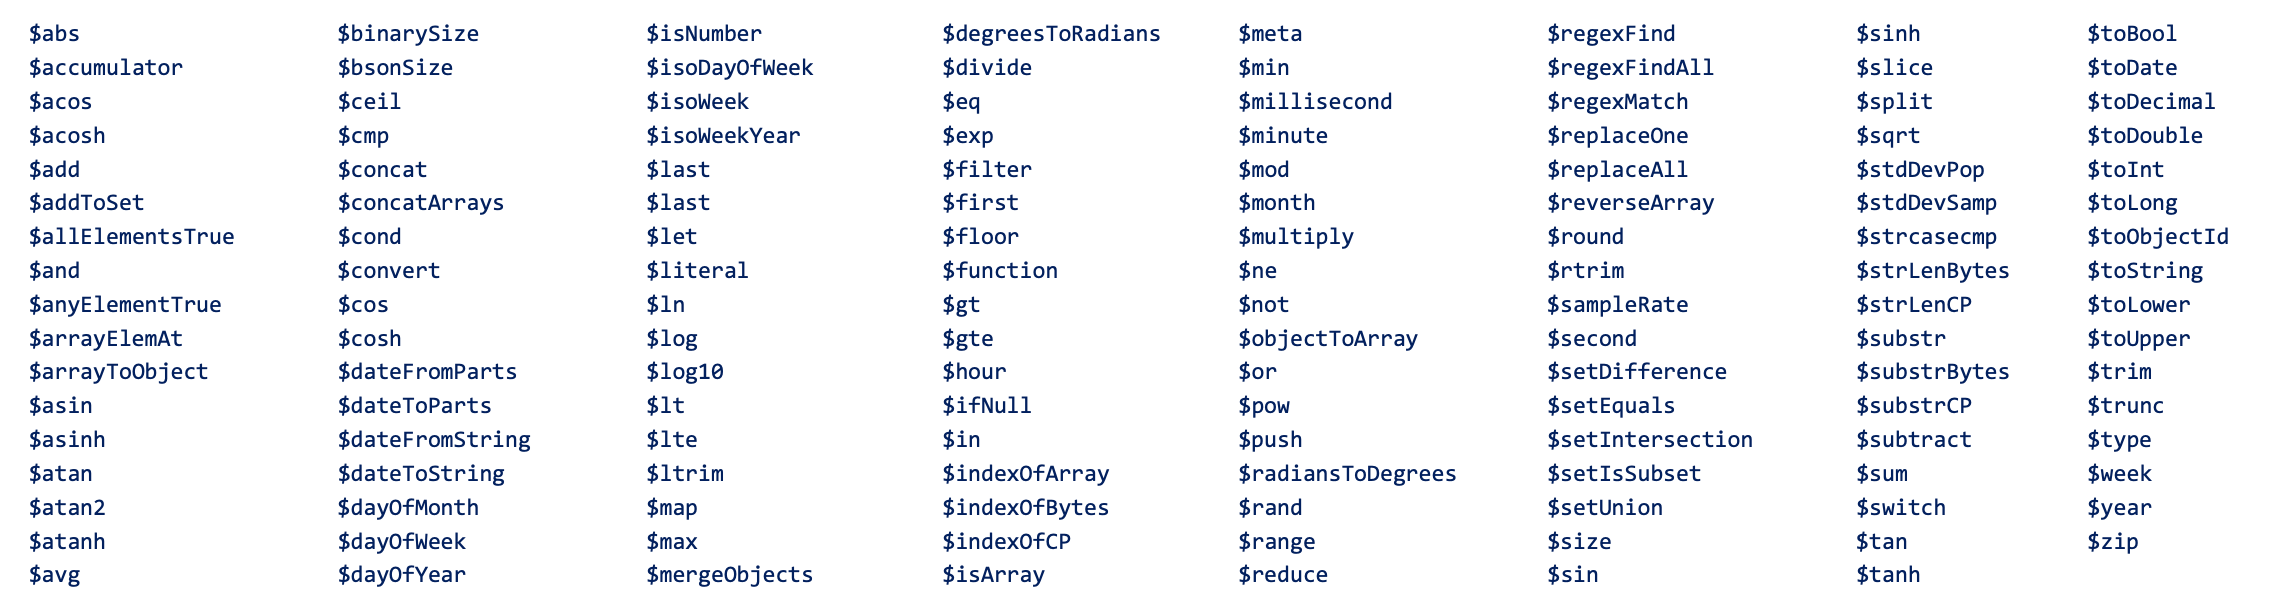

La liste est trop longue pour tous les introduire, on trouvera notamment un opérateur de condition ```$cond``` qui permet de réaliser des traitements distincts suivant l'évaluation d'une condition.
Dans l'exemple ci-dessous, on emploie ```$isArray```, ```$size``` et ```$cond``` pour conditionner la structure du document.

#### Rechercher le nombre d'investissements des entreprises acquises pour plus de 10 millions de dollars


```
db.companies.aggregate([
  { $match: { "acquisition.price_amount": { $gt: 10000000 } } },
  {
    $project: {
      _id: 1,
      name: 1,
      nbinvestments: {
        $cond: {
          if: { $isArray: "$investments" },
          then: { $size: "$investments" },
          else: null
        }
      }
    }
  },
  { $match: { nbinvestments: { $gt: 0 } } }
])
```

Le premier `$match` filtre les acquisitions coûteuses. `$isArray` protège le calcul avant l'utilisation de `$size`.

Le résultat d'une transformation peut être retourné au client ou être enregistré dans une collection grâce à la stage ```$out``` ou ```$merge```.

```$out``` va tout simplement nous permettre de stocker le résultat d'un traitement dans une nouvelle collection. Si la collection existe déjà, il supprime son contenu avant de ré-insérer le résultat.

https://docs.mongodb.com/manual/reference/operator/aggregation/out/

```
db.companies.aggregate([
{ $match: { "acquisition.price_amount": { $gt: 10000000 }} },
{ $project : 
    { _id : 1, 
      name: 1,
      nbinvestments: 
          { $cond: 
              { 
                if: 
                    { $isArray: "$investments" },
                then: 
                    { $size: "$investments" }, 
                else: null
              } 
           }
   }
},
{ $match: { "nbinvestments": { $gt: 5 }} },
{ $out : "myoutputfromscratch" }
])
```

Vous pouvez consulter les document de notre nouvelle collection :

```
db.myoutputfromscratch.find()
```

```$merge``` est le moyen de fusionner différents traitements dans une même collection.
Ajoutons dans notre collection myoutputfromscratch, les entreprises dont les investissements sont entre 3 et 4.

```
db.companies.aggregate([
{ $match: { "acquisition.price_amount": { $gt: 10000000 }}},
{ $project : 
    { _id : 1, 
      name: 1,
      nbinvestments: 
          { $cond: 
              { 
                if: 
                    { $isArray: "$investments" },
                then: 
                    { $size: "$investments" }, 
                else: null
              } 
           }
   }
},
{ 
    $match: { 
        $and: [ 
            {"nbinvestments": { $lte: 4 } }, 
            {"nbinvestments": { $gte: 3 } }
        ]
    }
},
{ $merge: { into: "myoutputfromscratch", on: "_id", whenMatched: "replace", whenNotMatched: "insert" } }
])
```

Les resultats ont été ajoutés sans supprimer le contenu existant.

## Exercice

Vous allez dans cette exerice travailler avec la collection trips.
Cette collection contient les déplacements des véliv à NY.

La structure d'un document est la suivante :

#### Regrouper les propriétés du cycliste dans un champs `biker` de manière à obtenir le résultat suivant ?



:::{admonition} Solution
:class: dropdown
```javascript
db.trips.aggregate([
  {
    $project: {
      _id: 1,
      tripduration: 1,
      bikeid: 1,
      "start station name": 1,
      "start station id": 1,
      "start station location": 1,
      "end station location": 1,
      "end station id": 1,
      "end station name": 1,
      "start time": 1,
      "stop time": 1,
      biker: {
        "birth year": "$birth year",
        gender: "$gender",
        usertype: "$usertype"
      }
    }
  }
])
```
`$project` reconstruit un document en ne conservant que les champs explicitement demandés.
:::

#### Réalisez la même transformation avec `$set` et `$unset` :



:::{admonition} Solution
:class: dropdown
```javascript
db.trips.aggregate([
  {
    $set: {
      biker: {
        "birth year": "$birth year",
        gender: "$gender",
        usertype: "$usertype"
      }
    }
  },
  { $unset: ["birth year", "gender", "usertype"] }
])
```
À la différence de `$project`, `$set` conserve les autres champs. `$unset` supprime ensuite uniquement les champs déplacés.
:::

#### Regrouper les propriétés du cycliste et des stations avec `$set` et `$unset`.


:::{admonition} Solution
:class: dropdown
```javascript
db.trips.aggregate([
  {
    $set: {
      biker: {
        "birth year": "$birth year",
        gender: "$gender",
        usertype: "$usertype"
      },
      "start station location": {
        "start station id": "$start station id",
        "start station name": "$start station name",
        type: "$start station location.type",
        coordinates: "$start station location.coordinates"
      },
      "end station location": {
        "end station id": "$end station id",
        "end station name": "$end station name",
        type: "$end station location.type",
        coordinates: "$end station location.coordinates"
      }
    }
  },
  {
    $unset: [
      "birth year",
      "gender",
      "usertype",
      "start station id",
      "start station name",
      "end station id",
      "end station name"
    ]
  }
])
```
La version corrigée conserve les coordonnées et le type GeoJSON tout en ajoutant les identifiants et noms dans les sous-documents de station.
:::

#### Enregistrez les sous-documents stations ("end/start station location") dans une collection stations :
* aucun doublon de station ne devra exister
* pour les plus courageux, on pourra définir un json schema sur la collection station


On pourra utiliser la structure suivante :

:::{hint} Indice : on utilise deux pipelines `$merge` pour alimenter une collection unique `stations`. Un premier pour insérer les stations de départ et un second pipeline pour insèrer les stations d'arrivée. Il faut bien garder à l'esprit qu'une station peut être cité comme point de départ pour certins trajets et point d'arrivé pour d'autres. Donc attention au doublon.
:::



:::{admonition} Solution
:class: dropdown
```javascript
db.createCollection("stations", {
  validator: {
    $jsonSchema: {
      bsonType: "object",
      required: ["station name", "type", "coordinates"],
      properties: {
        "station name": { bsonType: "string" },
        type: { enum: ["Point"] },
        coordinates: {
          bsonType: "array",
          minItems: 2,
          maxItems: 2,
          items: { bsonType: "double" }
        }
      }
    }
  }
})

db.trips.aggregate([
  {
    $project: {
      _id: "$start station id",
      "station name": "$start station name",
      type: "$start station location.type",
      coordinates: "$start station location.coordinates"
    }
  },
  { $merge: { into: "stations", on: "_id", whenMatched: "replace", whenNotMatched: "insert" } }
])

db.trips.aggregate([
  {
    $project: {
      _id: "$end station id",
      "station name": "$end station name",
      type: "$end station location.type",
      coordinates: "$end station location.coordinates"
    }
  },
  { $merge: { into: "stations", on: "_id", whenMatched: "replace", whenNotMatched: "insert" } }
])

db.stations.countDocuments()
```
Les deux pipelines convergent vers le même `_id` de station. Une station présente comme départ et arrivée n'est donc enregistrée qu'une seule fois.
:::

Vous devriez obtenir un total de 465 stations.

#### Créer une collection `trips2` qui conserve les références des stations, mais pas leurs propriétés détaillées.



:::{admonition} Solution
:class: dropdown
```javascript
db.trips.aggregate([
  {
    $project: {
      _id: 1,
      tripduration: 1,
      bikeid: 1,
      "start station id": 1,
      "end station id": 1,
      "start time": 1,
      "stop time": 1,
      biker: {
        "birth year": "$birth year",
        gender: "$gender",
        usertype: "$usertype"
      }
    }
  },
  { $out: "trips2" }
])
```
`trips2` contient les identifiants des stations comme références. Les détails restent dans `stations`.
:::

#### À partir de `trips2` et `stations`, utiliser l'aggregation framework pour afficher l'ensemble des données pour les trajets réalisés par le velo `17827` ?

On vous invite à utiliser 
* `$lookup` : https://www.mongodb.com/docs/manual/reference/operator/aggregation/lookup/
et 
* `$unwind` : https://www.mongodb.com/docs/manual/reference/operator/aggregation/unwind/


:::{admonition} Solution
:class: dropdown
```javascript
db.trips2.aggregate([
  { $match: { bikeid: 17827 } },
  {
    $lookup: {
      from: "stations",
      localField: "start station id",
      foreignField: "_id",
      as: "start station"
    }
  },
  { $unwind: "$start station" },
  {
    $lookup: {
      from: "stations",
      localField: "end station id",
      foreignField: "_id",
      as: "end station"
    }
  },
  { $unwind: "$end station" }
])
```
Deux `$lookup` sont nécessaires : un pour la station de départ et un pour la station d'arrivée. `$unwind` transforme chaque tableau de résultat en sous-document directement lisible.
:::

On peut vérifier le trajet dans la collection source :

```javascript
db.trips.find({ _id: ObjectId("572bb8222b288919b68abf5a") })
```

Le résultat permet de comparer le document original avec la version référencée de `trips2`.

Super !!! 
Nous pouvons reconstituer le contenu de notre trip en passant par les références.
